# Event Chain Extraction with Embedding Clustering

### Overview

runs after notebook 1 (cleaning). Reads `data/stylecom_cleaned.csv` for the original review text.

Input: `stylecom_cleaned.csv`, `cluster_labels.csv` (manually written in google sheets)

Outputs:
- `event_chains/triples_raw.jsonl`: raw triples
- `event_chains/event_type_map.json`: verb lemma assigned to cluster label
- `event_chains/domain_verb_diagnostics.csv`: poor-fit domain verbs for review
- `checkpoints/event_sequences.jsonl`: final per-review event sequences (verb + event label only)
- `checkpoints/event_sequences_full.jsonl`: same, but keeps subject/object/sentence_idx per event too

Pipeline:
- **1. Setup:** imports and checkpoint
- **2. NLP preprocessing with SpaCy & extracting triples:** Processes the dataset again, this time not only nouns, and extracts triples
- **3. Abstract verbs via embedding clustering:** Find optimal K and use sentence-transformers/all-MiniLM-L6-v2 to cluster verbs
- **4. Verb cluster diagnostics:** check verbs distance from centroid
- **5. Per-review event sequences:** Build a jsonl file of seuqences per review for further processing
- **6. Sanity checks:** Check overall distribution of assignments and short event sequences

### Variables

todo

## 1. Setup

In [9]:
# Cell 1: Imports
import json
import re
from collections import Counter
from itertools import pairwise
from pathlib import Path

import numpy as np
import pandas as pd
import spacy
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer
from sklearn.metrics import calinski_harabasz_score

In [10]:
# Cell 2: Paths
DATA_PATH        = Path("data/stylecom_cleaned.csv")
OUT_DIR          = Path("event_chains")
OUT_DIR.mkdir(exist_ok=True)
EVENT_LABELS_PATH = Path("data/event_labels.csv")

TRIPLES_PATH     = OUT_DIR / "triples_raw.jsonl"
MAP_PATH         = OUT_DIR / "event_type_map.json"
DIAG_PATH        = OUT_DIR / "domain_verb_diagnostics.csv"
SEQUENCE_PATH         = "checkpoints/event_sequences.jsonl"
FULL_SEQUENCE_PATH    = "checkpoints/event_sequences_full.jsonl"

# Variables
K_RANGE = range(5, 101, 5)
N_SEEDS = 10
REFERENCE_SEED = 42

## 2. NLP preprocessing with SpaCy & extracting triples

In [11]:
# Cell 4: Load data (use noun tokens dataframe)
df = pd.read_csv(DATA_PATH)

# Add doc_id
def assign_doc_id(df):
      if "doc_id" in df.columns:
          return df
      return df.reset_index(names="doc_id")

df = assign_doc_id(df)

print(f"Loaded {len(df)} reviews")
print("Columns:", df.columns.tolist())

Loaded 6501 reviews
Columns: ['doc_id', 'year', 'season', 'designer', 'author', 'city', 'date', 'review']


In [12]:
# Cell 5: Load spaCy, full pipeline
try:
    nlp = spacy.load("en_core_web_lg")
except OSError:
    raise OSError(
        "spaCy model not installed. Run:\n"
        "  python -m spacy download en_core_web_lg"
    )

nlp.max_length = max(2_000_000, nlp.max_length)
print("Loaded en_core_web_lg", nlp.pipe_names)

Loaded en_core_web_lg ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [13]:
# Cell 6: Helper function for extracting triples

def extract_triples_from_doc(doc, sentence_offset=0):
    """
    Extract triples from reviews, take passive verbs into account
    Lemmatize, 
    """
    triples = []
    for sent_idx, sent in enumerate(doc.sents):
        abs_sent_idx = sentence_offset + sent_idx
        for token in sent:
            if token.pos_ not in ("VERB", "AUX"):
                continue
            if token.dep_ in {"aux", "cop", "auxpass"}:
                continue

            verb_lemma = token.lemma_.lower()
            children = list(token.children)
            child_deps = {c.dep_: c for c in children}

            is_passive = (
                "nsubjpass" in child_deps
                or "auxpass" in child_deps
            )

            if is_passive:
                subj_token = child_deps.get("nsubjpass")
                subj = subj_token.lemma_.lower() if subj_token else None
                agent_token = child_deps.get("agent")
                if agent_token:
                    agent_children = {c.dep_: c for c in agent_token.children}
                    pobj = agent_children.get("pobj")
                    obj = pobj.lemma_.lower() if pobj else agent_token.lemma_.lower()
                else:
                    obj = None
            else:
                subj_token = child_deps.get("nsubj")
                subj = subj_token.lemma_.lower() if subj_token else None
                dobj_token = child_deps.get("dobj")
                obj = dobj_token.lemma_.lower() if dobj_token else None

            if subj is None:
                continue

            triples.append({
                "subject": subj,
                "verb": verb_lemma,
                "object": obj,
                "sentence_idx": abs_sent_idx,
                "is_passive": is_passive,
            })
    return triples

In [14]:
# Cell 7: Run spaCy over all reviews and save triples_raw.jsonl, uses original review text

restart = False

BATCH_SIZE = 64
texts = df["review"].fillna("").tolist()
columns = ['doc_id', 'year', 'season', 'designer', 'author', 'city', 'date', 'review']
df_spacy = df[columns].copy()

# Run full nlp pipeline on texts to normalize again
texts = nlp.pipe(texts, batch_size=BATCH_SIZE)

if restart:
    triples = []
    for (_, row), doc in zip(df_spacy.iterrows(), texts):
        doc_triples = extract_triples_from_doc(doc)
        triples.append({
            "review_id": int(row["doc_id"]),
            "brand":     str(row["designer"]),
            "year":      int(row["year"]) if not pd.isna(row["year"]) else None,
            "season":    str(row["season"]),
            "author":    str(row["author"]),
            "city":      str(row["city"]),
            "date":      str(row["date"]),
            "triples":   doc_triples,
        })

    with open(TRIPLES_PATH, "w") as f:
        for r in triples:
            f.write(json.dumps(r) + "\n")

    total_triples = sum(len(r["triples"]) for r in triples)
    print(f"Saved {len(triples)} reviews, {total_triples:,} tirples at {TRIPLES_PATH}")

In [15]:
if restart == False:
    triples = pd.read_json(TRIPLES_PATH, lines = True)

In [ ]:
# Cell 8a: Inspection

sample = triples.iloc[1]
print(f"Review {sample['review_id']}: {sample['brand']} {sample['season']} {sample['year']}")
print(f"  {len(sample['triples'])} triples")
for t in sample["triples"][:6]:
    print(f"  {t}")

Review 1: Giorgio Armani Spring 2000
  13 triples
  {'subject': 'armani', 'verb': 'propose', 'object': 'silhouette', 'sentence_idx': 0, 'is_passive': False}
  {'subject': 'foam', 'verb': 'infuse', 'object': 'collection', 'sentence_idx': 1, 'is_passive': False}
  {'subject': 'woman', 'verb': 'be', 'object': None, 'sentence_idx': 2, 'is_passive': False}
  {'subject': 'she', 'verb': 'be', 'object': None, 'sentence_idx': 2, 'is_passive': False}
  {'subject': 'innovation', 'verb': 'come', 'object': None, 'sentence_idx': 3, 'is_passive': False}
  {'subject': 'model', 'verb': 'wear', 'object': 'piece', 'sentence_idx': 3, 'is_passive': False}


In [ ]:
# Cell 8b: Count "be" triples with no object

n_total = 0
n_be = 0
n_be_no_obj = 0
for r in triples.itertuples():
    for t in r.triples:
        n_total += 1
        if t["verb"] == "be":
            n_be += 1
            if t["object"] is None:
                n_be_no_obj += 1

print(f"Total triples:              {n_total:,}")
print(f"'be' triples:               {n_be:,}  ({n_be/n_total:.1%} of all triples)")
print(f"'be' triples with no object: {n_be_no_obj:,}  "
      f"({n_be_no_obj/n_be:.1%} of 'be' triples, {n_be_no_obj/n_total:.1%} of all triples)")

Total triples:              119,370
'be' triples:               30,574  (25.6% of all triples)
'be' triples with no object: 30,557  (99.9% of 'be' triples, 25.6% of all triples)


In [18]:
# Cell 8c: Count "have" triples with and without object

n_have = 0
n_have_obj = 0
n_have_no_obj = 0
for r in triples.itertuples():
    for t in r.triples:
        if t["verb"] == "have":
            n_have += 1
            if t["object"] is None:
                n_have_no_obj += 1
            else:
                n_have_obj += 1

print(f"'have' triples:                {n_have:,}  ({n_have/n_total:.1%} of all triples)")
print(f"'have' triples WITH object:    {n_have_obj:,}  ({n_have_obj/n_have:.1%} of 'have' triples, lexical possession)")
print(f"'have' triples with NO object: {n_have_no_obj:,}  ({n_have_no_obj/n_have:.1%} of 'have' triples, mostly 'have to VERB')")

'have' triples:                4,446  (3.7% of all triples)
'have' triples WITH object:    3,631  (81.7% of 'have' triples, lexical possession)
'have' triples with NO object: 815  (18.3% of 'have' triples, mostly 'have to VERB')


## 3. Abstract verbs via embedding clustering

### 3.1 Get embeddings and run k sweep on clusters

In [12]:
# Cell 9: Collect verb lemmas and their corpus frequencies
# filters out non-alphabetic lemmas

verb_counter = Counter()
for r in triples.itertuples():
    for t in r.triples:
        verb = t["verb"]
        if not verb.isalpha():
            continue
        verb_counter[verb] += 1

unique_verbs = sorted(verb_counter.keys())
print(f"{len(unique_verbs)} unique verbs, {sum(verb_counter.values()):,} total tokens")

3293 unique verbs, 119,347 total tokens


In [13]:
# Cell 10: Compute verb embeddings with sentence-transformers

MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"
st_model = SentenceTransformer(MODEL_NAME)

verb_embeddings = st_model.encode(unique_verbs, show_progress_bar=True,
                                   batch_size=128, normalize_embeddings=True)
print(f"Embeddings shape: {verb_embeddings.shape}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 20798.55it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 26/26 [00:01<00:00, 13.27it/s]

Embeddings shape: (3293, 768)


In [22]:
# Cell 11: Sweep k and select by silhouette score, CH score

results = []

for k in K_RANGE:
    ref_km = KMeans(n_clusters=k, random_state=REFERENCE_SEED, n_init=10)
    ref_labels = ref_km.fit_predict(verb_embeddings)

    sil_scores = []
    ch_scores = []

    for seed in range(N_SEEDS):
        km = KMeans(n_clusters=k, random_state=seed, n_init=10)
        labels = km.fit_predict(verb_embeddings)
        sil_scores.append(silhouette_score(verb_embeddings, labels, sample_size=min(5000, len(unique_verbs)), metric="cosine"))
        ch_scores.append(calinski_harabasz_score(verb_embeddings, labels))

    mean_sil = float(np.mean(sil_scores))
    std_sil  = float(np.std(sil_scores))
    mean_ch  = float(np.mean(ch_scores))
    std_ch  = float(np.std(ch_scores))


    results.append({
        "k": k,
        "mean_silhouette": mean_sil,
        "std_silhouette": std_sil,
        "mean_ch": mean_ch,
        "std_ch": std_ch
    })

    print(f"k={k:3d}  sil={mean_sil:.4f} (+/-{std_sil:.4f})  CH={mean_ch:.4f} (+/-{std_ch:.4f})")

k=  5  sil=0.0307 (+/-0.0003)  CH=44.9912 (+/-0.0270)
k= 10  sil=0.0297 (+/-0.0006)  CH=30.3798 (+/-0.1043)
k= 15  sil=0.0322 (+/-0.0009)  CH=24.2449 (+/-0.0745)
k= 20  sil=0.0343 (+/-0.0010)  CH=20.6742 (+/-0.0826)
k= 25  sil=0.0356 (+/-0.0013)  CH=18.1648 (+/-0.1017)
k= 30  sil=0.0361 (+/-0.0008)  CH=16.3465 (+/-0.0947)
k= 35  sil=0.0379 (+/-0.0011)  CH=14.9669 (+/-0.0524)
k= 40  sil=0.0375 (+/-0.0015)  CH=13.7795 (+/-0.0566)
k= 45  sil=0.0385 (+/-0.0027)  CH=12.9112 (+/-0.0689)
k= 50  sil=0.0385 (+/-0.0020)  CH=12.1133 (+/-0.0713)
k= 55  sil=0.0407 (+/-0.0011)  CH=11.4733 (+/-0.0501)
k= 60  sil=0.0401 (+/-0.0017)  CH=10.8976 (+/-0.0542)
k= 65  sil=0.0397 (+/-0.0011)  CH=10.3691 (+/-0.0462)
k= 70  sil=0.0403 (+/-0.0015)  CH=9.9858 (+/-0.0529)
k= 75  sil=0.0411 (+/-0.0021)  CH=9.5645 (+/-0.0427)
k= 80  sil=0.0409 (+/-0.0014)  CH=9.2355 (+/-0.0511)
k= 85  sil=0.0426 (+/-0.0016)  CH=8.9184 (+/-0.0284)
k= 90  sil=0.0428 (+/-0.0020)  CH=8.6483 (+/-0.0403)
k= 95  sil=0.0439 (+/-0.0017)  CH

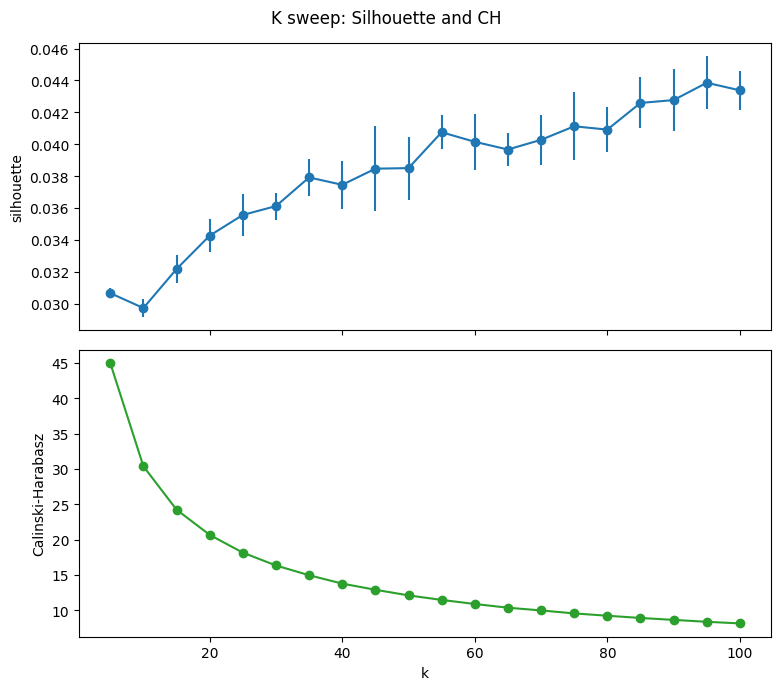

In [ ]:
ks = [r["k"] for r in results]
mean_sil = [r["mean_silhouette"] for r in results]
std_sil  = [r["std_silhouette"] for r in results]
mean_ch  = [r["mean_ch"] for r in results]
std_ch   = [r["std_ch"] for r in results]

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

axes[0].errorbar(ks, mean_sil, yerr=std_sil, marker="o", color="tab:blue")
axes[0].set_ylabel("silhouette")

axes[1].errorbar(ks, mean_ch, yerr=std_ch, marker="o", color="tab:green")
axes[1].set_ylabel("Calinski-Harabasz")
axes[1].set_xlabel("k")

fig.suptitle("K sweep: Silhouette and CH")
plt.tight_layout()
plt.show()

In [ ]:
# Cell 12: Save top-10 verbs per cluster per K between 10-50 with steps of 10 for manual inpsection

K_CANDIDATES = range(10, 51, 5)
rows = []

for k in K_CANDIDATES:
    km = KMeans(n_clusters=k, random_state=REFERENCE_SEED, n_init=10)
    labels = km.fit_predict(verb_embeddings)

    cluster_verbs = {}
    for verb, label in zip(unique_verbs, labels):
        cluster_verbs.setdefault(int(label), []).append(verb)

    for cluster_id in sorted(cluster_verbs):
        top = sorted(cluster_verbs[cluster_id], key=lambda v: verb_counter[v], reverse=True)[:10]
        freq_total = sum(verb_counter[v] for v in cluster_verbs[cluster_id])
        rows.append({
            "k": k,
            "cluster_id": cluster_id,
            "n": len(cluster_verbs[cluster_id]),
            "freq": freq_total,
            "top_verbs": ", ".join(top),
        })

    print(f"k={k}: {len(cluster_verbs)} clusters processed")

inspection_df = pd.DataFrame(rows)
inspection_df.to_csv("event_chains/cluster_inspection_by_k.csv", index=False)

k=10: 10 clusters processed
k=15: 15 clusters processed
k=20: 20 clusters processed
k=25: 25 clusters processed
k=30: 30 clusters processed
k=35: 35 clusters processed
k=40: 40 clusters processed
k=45: 45 clusters processed
k=50: 50 clusters processed
Saved 270 rows to checkpoints/cluster_inspection_by_k.csv


### 3.2 Result of manual inspection

Note: the csv `cluster_inpection_by_k.csv` was imported into google drive and manually evaluated there. Based on this evaluation, k = 30 was set as the best k. Then, labels were assigned to the cluster results from k = 30. These are imported below

In [ ]:
# Cell 13: Load event labels from csv

with open(MAP_PATH) as f:
      event_type_map = json.load(f)

event_label_df = pd.read_csv(EVENT_LABELS_PATH)

print(f"Loaded {len(event_type_map)} verb to label mappings from {MAP_PATH}")

Loaded 3293 verbs across 30 old labels


## 4. Verb cluster diagnostics

In [56]:
# Cell 14: Compute each verb's distance to its assigned cluster centroid
centroids = best_km.cluster_centers_

distances = []
for verb, label, emb in zip(unique_verbs, best_labels, verb_embeddings):
    dist = float(np.linalg.norm(emb - centroids[label]))
    distances.append({
        "verb":             verb,
        "frequency":        verb_counter[verb],
        "assigned_cluster": CLUSTER_LABELS[int(label)],
        "centroid_distance": dist,
    })

diagnostic_df = pd.DataFrame(distances)
diagnostic_df = diagnostic_df.sort_values("centroid_distance", ascending=False)

diagnostic_df

,verb,frequency,assigned_cluster,centroid_distance
1251,getexcite,1,Direction & Showcase,0.981139
1033,except,1,Cognition,0.976640
3213,welcome,7,Generic Action,0.974706
736,define,92,Allusion,0.974505
1894,override,2,Transformation,0.974208
...,...,...,...,...
2276,reintroduce,4,Reinterpretation,0.655724
2229,recur,12,Reinterpretation,0.649500
2210,rechristene,3,Reinterpretation,0.648788
2241,redrafte,1,Reinterpretation,0.647110


In [57]:
# Cell 15: Save diagnostics table
diagnostic_df.to_csv(DIAG_PATH, index=False)
print(f"Saved {len(diagnostic_df)} rows to {DIAG_PATH}")

Saved 3293 rows to event_chains/domain_verb_diagnostics.csv


## 5. Per-review event sequences

In [58]:
# Cell 16: Map verbs to event types and save event_sequences.jsonl

# iterrows() handles both DataFrame (restart=False) and list-of-dicts (restart=True)
_rows = triples.iterrows() if hasattr(triples, 'iterrows') else enumerate(triples)

sequences = []
for _, r in _rows:
    events = []
    for t in r["triples"]:
        event_type = event_type_map.get(t["verb"], "UNMAPPED")
        events.append({
            "event":      event_type,
            "verb":       t["verb"],
            "is_passive": t["is_passive"],
        })
    sequences.append({
        "review_id": r["review_id"],
        "brand":     r["brand"],
        "year":      r["year"],
        "season":    r["season"],
        "author":    r["author"],
        "city":      r["city"],
        "events":    events,
    })

with open(SEQUENCE_PATH, "w") as f:
    for s in sequences:
        f.write(json.dumps(s) + "\n")

print(f"Saved {len(sequences)} event sequences to {SEQUENCE_PATH}")

Saved 6501 event sequences to checkpoints/event_sequences.jsonl


## 6. Sanity checks

In [60]:
# Cell 17: Top-20 verb lemmas before and after abstraction

print("Top 20 verb lemmas before clustering")
for v, c in verb_counter.most_common(20):
    print(f"  {v:25s}  {c:>6,}  :  {event_type_map.get(v, 'UNMAPPED')}")

print()
event_counter = Counter()
for s in sequences:
    for e in s["events"]:
        event_counter[e["event"]] += 1

print(f"All event types after clustering ({len(event_counter)} total)")
for et, c in event_counter.most_common():
    print(f"  {c:>7,}  {et}")

Top 20 verb lemmas before clustering
  be                         30,574  :  Being & Presentation
  have                        4,446  :  Generic Action
  say                         2,829  :  Cognition
  look                        2,790  :  Perception
  make                        2,657  :  Construction & Composition
  come                        2,476  :  Initiation
  do                          1,840  :  Cognition
  go                          1,509  :  Initiation
  show                        1,454  :  Being & Presentation
  take                        1,401  :  Generic Action
  seem                        1,352  :  Perception
  want                        1,318  :  Generic Action
  feel                        1,207  :  Perception
  get                         1,143  :  Generic Action
  wear                        1,018  :  Garment & Styling
  work                          979  :  Continuation & Development
  see                           865  :  Perception
  give                 

In [ ]:
# Drop UNMAPPED events from sequences and re-save

before = sum(len(s["events"]) for s in sequences)

for s in sequences:
    s["events"] = [e for e in s["events"] if e["event"] != "UNMAPPED"]

after = sum(len(s["events"]) for s in sequences)

with open(SEQUENCE_PATH, "w") as f:
    for s in sequences:
        f.write(json.dumps(s) + "\n")

print(f"Dropped {before - after} UNMAPPED events")
print(f"Re-saved {len(sequences)} sequences to {SEQUENCE_PATH}")

Dropped 23 UNMAPPED events (119370 → 119347)
Re-saved 6501 sequences to checkpoints/event_sequences.jsonl


In [ ]:
# Save full per-review event sequences (subject, verb, object kept, not just verb + event label)

full_sequences = []
_rows = triples.iterrows() if hasattr(triples, 'iterrows') else enumerate(triples)
for _, r in _rows:
    events = []
    for t in r["triples"]:
        event_type = event_type_map.get(t["verb"], "UNMAPPED")
        if event_type == "UNMAPPED":
            continue
        events.append({
            "event":        event_type,
            "subject":      t["subject"],
            "verb":         t["verb"],
            "object":       t["object"],
            "is_passive":   t["is_passive"],
            "sentence_idx": t["sentence_idx"],
        })
    full_sequences.append({
        "review_id": r["review_id"],
        "brand":     r["brand"],
        "year":      r["year"],
        "season":    r["season"],
        "author":    r["author"],
        "city":      r["city"],
        "events":    events,
    })

with open(FULL_SEQUENCE_PATH, "w") as f:
    for s in full_sequences:
        f.write(json.dumps(s) + "\n")

print(f"Saved {len(full_sequences)} full event sequences to {FULL_SEQUENCE_PATH}")

In [66]:
# Cell 18: Passive vs. active breakdown overall and per event type

_rows = triples.iterrows() if hasattr(triples, 'iterrows') else enumerate(triples)
all_triples = [t for _, r in _rows for t in r["triples"]]
n_passive = sum(t["is_passive"] for t in all_triples)
n_total   = len(all_triples)
print(f"Overall: {n_passive:,} passive / {n_total:,} total = {n_passive/n_total:.1%}")

# Per event type
et_passive = {}
et_total   = {}
_rows2 = triples.iterrows() if hasattr(triples, 'iterrows') else enumerate(triples)
for _, r in _rows2:
    for t in r["triples"]:
        et = event_type_map.get(t["verb"], "UNMAPPED")
        et_total[et]   = et_total.get(et, 0) + 1
        et_passive[et] = et_passive.get(et, 0) + int(t["is_passive"])

print("Passive rate per event type")
rows = [(et, et_passive[et], et_total[et], et_passive[et]/et_total[et])
        for et in et_total]
rows.sort(key=lambda x: x[3], reverse=True)
print(f"{'Event type':<38} {'Passive':>8} {'Total':>8} {'Rate':>6}")
for et, n_p, n_t, rate in rows:
    print(f"  {et:<36} {n_p:>8,} {n_t:>8,} {rate:>6.1%}")

Overall: 8,883 passive / 119,370 total = 7.4%
Passive rate per event type
Event type                              Passive    Total   Rate
  Design & Ornamentation                    532    1,428  37.3%
  Garment & Styling                         525    1,849  28.4%
  Tailoring                                 567    2,038  27.8%
  Transformation                            189      918  20.6%
  Direction & Showcase                      351    1,851  19.0%
  Ornamentation                             150      795  18.9%
  Fluid Motion                              138      748  18.4%
  Combination                               163      896  18.2%
  Stylistic Adjustment                       60      349  17.2%
  Reinterpretation                          143      868  16.5%
  Runway Motion                              91      599  15.2%
  Resistance                                 78      516  15.1%
  Rejection & Departure                     130      889  14.6%
  Spatial Placement           

In [62]:
# Cell 19: Inspect reviews with empty or very short event sequences
short_reviews = [
    {"review_id": s["review_id"], "brand": s["brand"],
     "year": s["year"], "n_events": len(s["events"])}
    for s in sequences if len(s["events"]) < 2
]

print(f"Reviews with < 2 events: {len(short_reviews)} / {len(sequences)}")
if short_reviews:
    print(pd.DataFrame(short_reviews).to_string(index=False))

Reviews with < 2 events: 9 / 6501
 review_id                 brand  year  n_events
      4031    Christophe Lemaire  2011         1
      4521            John Rocha  2012         1
      5377         ZAC Zac Posen  2013         1
      5384 McQ Alexander McQueen  2013         1
      5469           Gary Graham  2013         1
      5643                   Sea  2014         1
      5729                  Daks  2014         1
      6028            James Long  2014         1
      6111                 Chloé  2014         1
